In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering


In [ ]:
#загрузка данных

df = pd.read_csv("/content/Mall_Customers.csv.xls")

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


пропусков нет, все столбцы кроме Gender в числовом формате

In [ ]:
df.Gender.value_counts()

,count
Gender,
Female,112
Male,88


Gender - категориальный (бинарный), а KMeans предполагает непрерывные признаки, расстояние между "мужчина = 0" и "женщина = 1" интерпретируется как количественное, хотя на самом деле это качественное различие.
убираем его

In [ ]:
#подготовка данных
#используются только числовые признаки

X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
# обязательно использовать scaler, kmeans чувствителен к масштабу
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
X_scaled[:6]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627]])

KMeans
- init - k-mean++ - Алгоритм выбирает начальные центроиды кластеров, используя выборку на основе эмпирического распределения вероятностей вклада точек в общую инерцию. Этот метод ускоряет сходимость. Реализованный алгоритм — «жадный k-средних++». Он отличается от стандартного k-средних++ тем, что на каждом шаге выборки проводится несколько пробных попыток, и из них выбирается лучший центроид.
- n_init - число раз которое прокручивается алгоритм с разными центроидами.
- inertia - Сумма квадратов расстояний образцов до ближайшего центра кластера, взвешенная с учетом весов образцов, если таковые имеются.

Метод локтя

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [ ]:
wcss

[599.9999999999999,
 389.38618895643714,
 295.21224615554877,
 205.22514747675913,
 168.2475801755683,
 133.86842085478855,
 117.01155455889815,
 103.87329152383714,
 93.0928911004172,
 82.38515364526597]

здесь резкое убывание на k=5. чем меньше wcss тем плотнее кластеры

Силуетный коэффициент

In [ ]:
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

In [ ]:
silhouette_scores

[np.float64(0.33547192894004574),
 np.float64(0.357793388710272),
 np.float64(0.4039582785148566),
 np.float64(0.41664341513732767),
 np.float64(0.4284167762892593),
 np.float64(0.417231894954916),
 np.float64(0.4082067042807375),
 np.float64(0.41769250624076476),
 np.float64(0.40655411010117015)]

Здесь на k=5 и k=6 видны явные скачки к 1. кластеры плотные и хорошо разделены

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

k_opt = 6
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = labels

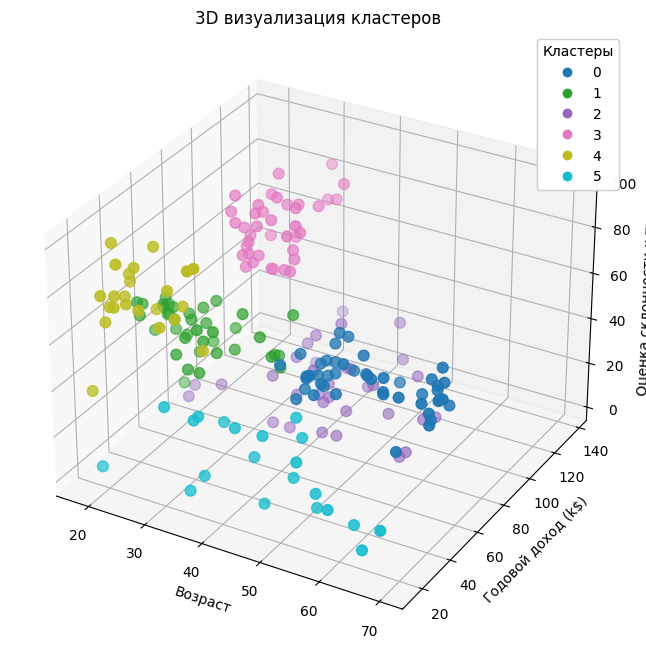

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='tab10',
    s=60
)

ax.set_xlabel('Возраст')
ax.set_ylabel('Годовой доход (k$)')
ax.set_zlabel('Оценка склонности к тратам')
ax.set_title('3D визуализация кластеров')


legend1 = ax.legend(*scatter.legend_elements(), title="Кластеры")
ax.add_artist(legend1)

plt.show()

Сравнение 2х моделей

здесь не используется Gridseаrch т.к
- нет целевой перемееннной
- не классические метрики

In [ ]:
k_values = range(2, 11)

results = {
    'KMeans': {'k': [], 'silhouette': []},
    'Agglomerative': {'k': [], 'silhouette': []}
}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = kmeans.fit_predict(X_scaled)
    score_km = silhouette_score(X_scaled, labels_km)

    results['KMeans']['k'].append(k)
    results['KMeans']['silhouette'].append(score_km)

    agg = AgglomerativeClustering(n_clusters=k)
    labels_agg = agg.fit_predict(X_scaled)
    score_agg = silhouette_score(X_scaled, labels_agg)

    results['Agglomerative']['k'].append(k)
    results['Agglomerative']['silhouette'].append(score_agg)

best_k_km = results['KMeans']['k'][np.argmax(results['KMeans']['silhouette'])]
best_score_km = max(results['KMeans']['silhouette'])

best_k_agg = results['Agglomerative']['k'][np.argmax(results['Agglomerative']['silhouette'])]
best_score_agg = max(results['Agglomerative']['silhouette'])

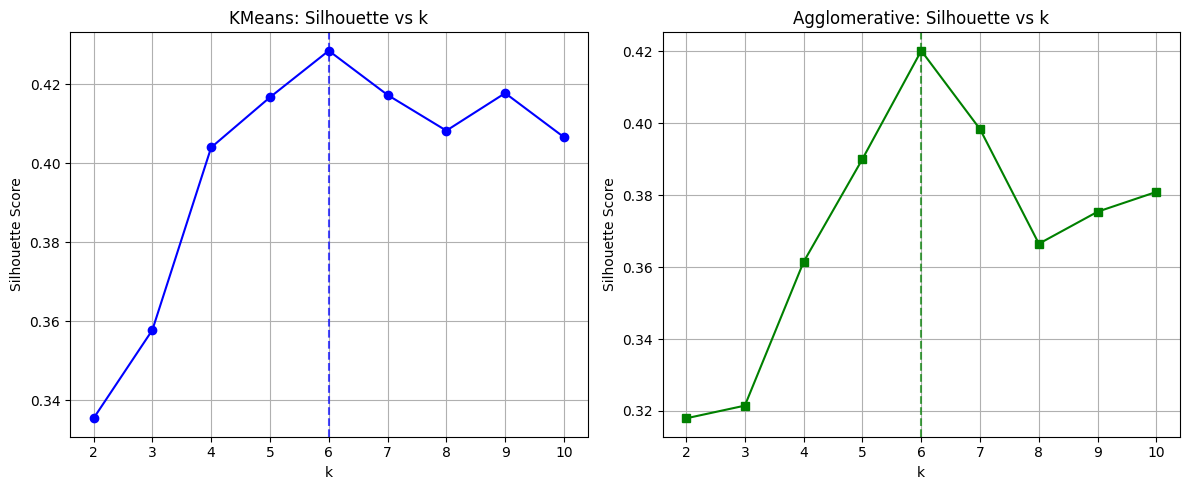

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results['KMeans']['k'], results['KMeans']['silhouette'],
         marker='o', label='KMeans', color='blue')
plt.axvline(best_k_km, color='blue', linestyle='--', alpha=0.7)
plt.title('KMeans: Silhouette vs k')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(results['Agglomerative']['k'], results['Agglomerative']['silhouette'],
         marker='s', label='Agglomerative', color='green')
plt.axvline(best_k_agg, color='green', linestyle='--', alpha=0.7)
plt.title('Agglomerative: Silhouette vs k')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

На графиках видно, что оптимальное количество кластеров для обеих моделей является 6

Визуализация локтя и силуэта только для KMeans

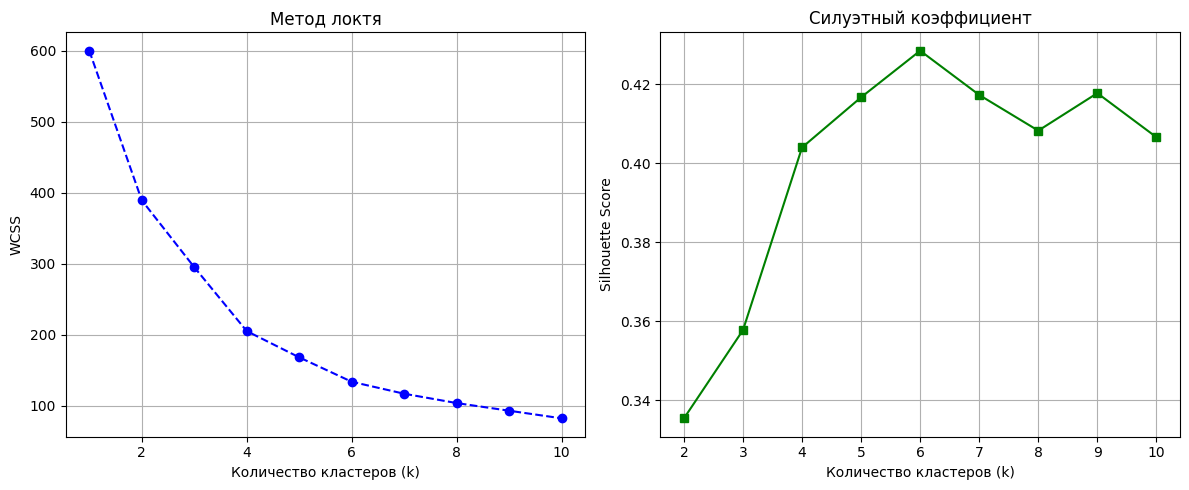

In [ ]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='blue')
plt.title('Метод локтя')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('WCSS')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='green')
plt.title('Силуэтный коэффициент')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

График слева(Метод локтя) показывает, как уменьшается внутрикластерная сумма квадратов (WCSS) при увеличении числа кластеров k.
Чем меньше WCSS, тем компактнее кластеры.

График справа(Силуетный коэффициент), измеряет качество кластеризации: чем ближе значение к 1, тем лучше.
Виден максимум при k => это наиболее чёткое разделение данных.